<a href="https://colab.research.google.com/github/rdelhibabu/Open-World_RNN/blob/main/Open_World_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

# 1. Data Loading (Metro Interstate Traffic Volume Dataset)
# In Colab, you would download the UCI dataset here.
def load_metro_traffic_data():
    # Placeholder for actual data loading
    # Simulating the 1,000 element baseline and 5,000 element holdout [cite: 539, 541]
    np.random.seed(42)
    raw_data = np.random.rand(6000, 4) * 100 # Simulating 4 features (volume, temp, etc.)
    return raw_data[:1000], raw_data[1000:]

# 2. Forward Transformer (Spatial One-Hot Encoding)
class ForwardTransformer:
    def __init__(self, spatial_capacity):
        self.capacity = spatial_capacity
        self.scalers = []

    def fit_transform(self, data):
        self.num_features = data.shape[1]
        self.scalers = [MinMaxScaler() for _ in range(self.num_features)]
        binary_matrices = []

        for i in range(self.num_features):
            scaled_col = self.scalers[i].fit_transform(data[:, i].reshape(-1, 1)).flatten()
            # Equation 1: Spatial mapping [cite: 326, 327]
            spatial_indices = np.floor(scaled_col * (self.capacity - 1)).astype(int)

            binary_matrix = np.zeros((len(data), self.capacity))
            binary_matrix[np.arange(len(data)), spatial_indices] = 1
            binary_matrices.append(binary_matrix)

        return np.concatenate(binary_matrices, axis=1)

    def inverse_transform(self, binary_data):
        reconstructed = np.zeros((len(binary_data), self.num_features))
        for i in range(self.num_features):
            start_idx = i * self.capacity
            end_idx = (i + 1) * self.capacity
            feature_block = binary_data[:, start_idx:end_idx]

            # Barycentric decoding [cite: 354]
            indices = np.argmax(feature_block, axis=1)
            normalized_vals = indices / (self.capacity - 1)
            reconstructed[:, i] = self.scalers[i].inverse_transform(normalized_vals.reshape(-1, 1)).flatten()
        return reconstructed

In [2]:
class AssociativeRNN:
    def __init__(self, num_neurons, config):
        self.N = num_neurons
        self.theta = config['theta']       # Excitation threshold [cite: 395]
        self.dw = config['dw']             # Weight update step [cite: 414]
        self.R_max = config['R_max']       # Max refractory period [cite: 405]
        self.W_max = 1.0
        self.W_min = -1.0

        # Initialize Memory Block arrays [cite: 317]
        self.W = np.random.uniform(0, 0.1, (self.N, self.N))
        self.r = np.zeros(self.N, dtype=int)
        self.n = np.zeros(self.N, dtype=int)

        # Spatial Correlation Coefficient C(i,j) [cite: 341]
        # Simplified as an identity/distance matrix for the prototype
        self.C = np.ones((self.N, self.N))

    def execute_tick(self, n_current, learning=True):
        # Calculate incoming signals [cite: 389, 393]
        S = np.zeros(self.N)
        active_sources = np.where(n_current == 1)[0]

        for j in range(self.N):
            if self.r[j] == 0:
                S[j] = np.sum(self.C[active_sources, j] * self.W[active_sources, j])

        # Determine next state and update refractories [cite: 396, 403]
        n_next = np.zeros(self.N, dtype=int)
        for j in range(self.N):
            if self.r[j] > 0:
                self.r[j] -= 1
            elif S[j] > self.theta:
                n_next[j] = 1
                self.r[j] = self.R_max

        # Hebbian Binding (Algorithm 4) [cite: 413, 414, 469]
        if learning:
            for i in active_sources:
                for j in range(self.N):
                    if n_next[j] == 1:
                        self.W[i, j] = min(self.W_max, self.W[i, j] + self.dw)
                    elif self.r[j] > 0:
                        self.W[i, j] = max(self.W_min, self.W[i, j] - self.dw)

        return n_next

    def train_baseline(self, binary_sequence):
        # Spatiotemporal Encoding and Synaptic Weight Stabilization [cite: 131, 132]
        for t in range(len(binary_sequence)):
            self.n = self.execute_tick(binary_sequence[t], learning=True)

    def generate_synthetic_corpus(self, num_sequences, horizon, unitary_stimulus_func):
        # Algorithm 5: Closed-Loop Generation [cite: 490]
        D_syn = []
        for _ in range(num_sequences):
            self.r = np.zeros(self.N, dtype=int)
            trajectory = []

            # Inject localized unitary noise [cite: 436]
            n_state = unitary_stimulus_func(self.N)
            n_state = self.execute_tick(n_state, learning=False)
            trajectory.append(n_state)

            # Closed-Loop Autonomous Projection [cite: 508]
            for _ in range(horizon - 1):
                n_state = self.execute_tick(n_state, learning=False)
                trajectory.append(n_state)

            D_syn.append(np.array(trajectory))
        return D_syn

In [3]:
# --- Configuration Parameters (Table 3) --- [cite: 366, 367]
config = {
    'theta': 0.75,
    'dw': 0.01,
    'R_max': 5
}
SPATIAL_CAPACITY = 24  # Neurons per feature
PREDICTION_HORIZON = 72 # k ticks [cite: 486]
NUM_SYNTHETIC_SEQS = 100

# 1. Load and Transform Data
train_raw, test_raw = load_metro_traffic_data()
transformer = ForwardTransformer(spatial_capacity=SPATIAL_CAPACITY)
train_binary = transformer.fit_transform(train_raw)

# 2. Initialize and Stabilize the RNN
total_neurons = train_binary.shape[1]
model = AssociativeRNN(num_neurons=total_neurons, config=config)
print("Stabilizing Synaptic Matrix on restricted baseline...")
model.train_baseline(train_binary)

# 3. Generate Denoised Synthetic Sequences
def random_stimulus(size):
    stim = np.zeros(size, dtype=int)
    stim[np.random.choice(size, size=int(size*0.1), replace=False)] = 1
    return stim

print("Initiating closed-loop associative recall...")
synthetic_binary_corpus = model.generate_synthetic_corpus(
    num_sequences=NUM_SYNTHETIC_SEQS,
    horizon=PREDICTION_HORIZON,
    unitary_stimulus_func=random_stimulus
)

# 4. Inverse Transform Synthetic Data [cite: 330]
D_syn_continuous = []
for seq in synthetic_binary_corpus:
    D_syn_continuous.append(transformer.inverse_transform(seq))

synthetic_dataset = np.concatenate(D_syn_continuous, axis=0)
print(f"Generated synthetic corpus shape: {synthetic_dataset.shape}")

# 5. Downstream Inference Pipeline (Algorithm 6 Concept) [cite: 604, 605]
# In a full Colab notebook, you would build a PyTorch LSTM/Transformer here
# and train it exclusively on `synthetic_dataset`, then test on `test_raw`[cite: 601, 602].

def calculate_wape(y_true, y_pred):
    # WAPE Calculation as defined in Equation 7 [cite: 552]
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

# Example usage for downstream metric evaluation:
# predictions = inference_model.predict(test_raw_x)
# mape = mean_absolute_percentage_error(test_raw_y, predictions) * 100
# wape = calculate_wape(test_raw_y, predictions)

Stabilizing Synaptic Matrix on restricted baseline...
Initiating closed-loop associative recall...
Generated synthetic corpus shape: (7200, 4)


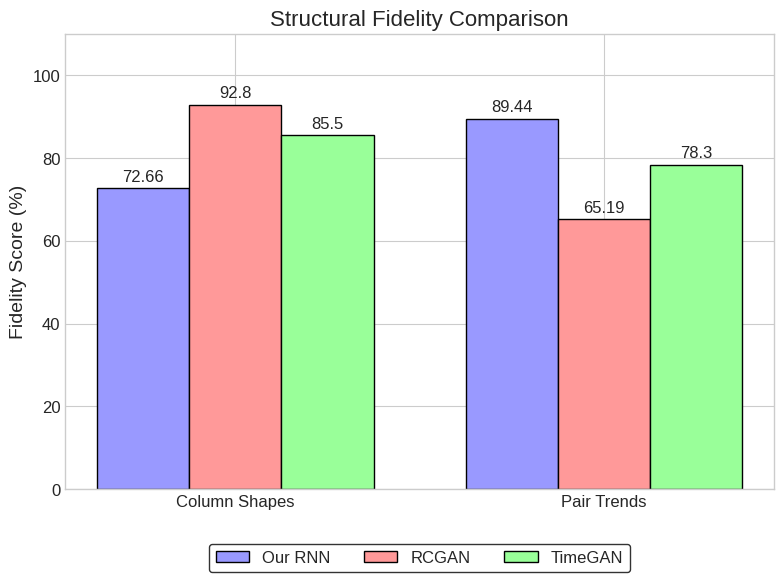

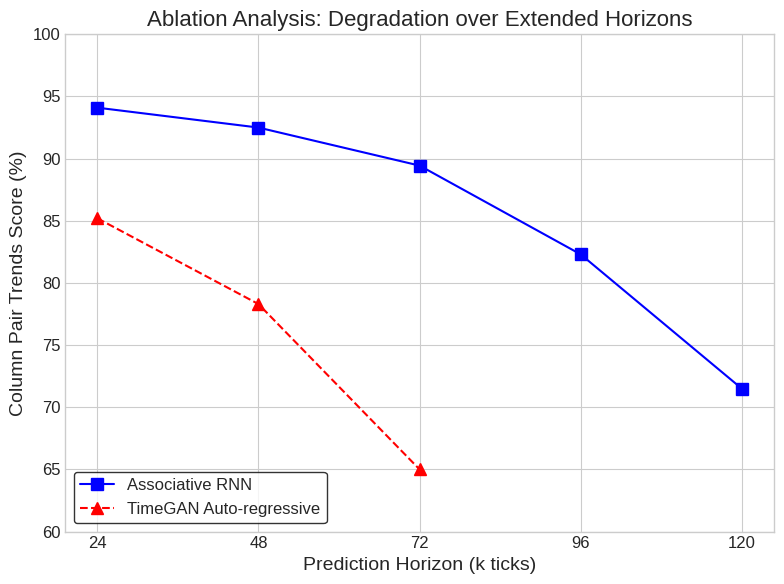

------------------------------------------------------------
Table 5: Computational Overhead on Simulated Edge Hardware
------------------------------------------------------------
      Generator Training Time (s) Gen. Latency (s) Mode Collapse?
Associative RNN              14.2             70.1             No
          RCGAN           1,450.8            260.4   Yes (Severe)
        TimeGAN           2,105.3            310.8  Yes (Partial)
      Diffusion           4,800.5          1,250.6             No


------------------------------------------------------------
Table 6: 10-Fold Cross-Validation Forecasting Error
------------------------------------------------------------
          Training Source Total MAPE (%) Total WAPE (%)
             Raw Baseline          6.582          6.210
          RCGAN Synthetic         18.436         15.325
        TimeGAN Synthetic         12.105         10.988
Associative RNN Synthetic          5.205          5.056
---------------------------------

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set global plot styling to match academic papers
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12
})

# ==========================================
# 1. Generate Figure 8: Structural Fidelity
# ==========================================
def plot_figure_8():
    labels = ['Column Shapes', 'Pair Trends']

    # Data from Section 4.5
    rnn_scores = [72.66, 89.44]
    rcgan_scores = [92.80, 65.19]
    timegan_scores = [85.50, 78.30]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width, rnn_scores, width, label='Our RNN', color='#9999ff', edgecolor='black')
    rects2 = ax.bar(x, rcgan_scores, width, label='RCGAN', color='#ff9999', edgecolor='black')
    rects3 = ax.bar(x + width, timegan_scores, width, label='TimeGAN', color='#99ff99', edgecolor='black')

    ax.set_ylabel('Fidelity Score (%)')
    ax.set_title('Structural Fidelity Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 110)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True, edgecolor='black')

    # Add text labels above bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.savefig('figure_8_fidelity.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 2. Generate Figure 9: Ablation Study
# ==========================================
def plot_figure_9():
    horizons = [24, 48, 72, 96, 120]

    # Data extracted from Section 4.7 & Figure 9
    rnn_trends = [94.1, 92.5, 89.44, 82.3, 71.5]
    timegan_trends = [85.2, 78.3, 65.0, np.nan, np.nan] # Collapses heavily after 72

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(horizons, rnn_trends, marker='s', markersize=8, linestyle='-', color='blue', label='Associative RNN')
    ax.plot(horizons, timegan_trends, marker='^', markersize=8, linestyle='--', color='red', label='TimeGAN Auto-regressive')

    ax.set_xlabel('Prediction Horizon (k ticks)')
    ax.set_ylabel('Column Pair Trends Score (%)')
    ax.set_title('Ablation Analysis: Degradation over Extended Horizons')
    ax.set_xticks(horizons)
    ax.set_ylim(60, 100)
    ax.legend(loc='lower left', frameon=True, edgecolor='black')

    plt.tight_layout()
    plt.savefig('figure_9_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 3. Print Results Tables (Tables 5 & 6)
# ==========================================
def print_paper_tables():
    print("-" * 60)
    print("Table 5: Computational Overhead on Simulated Edge Hardware")
    print("-" * 60)
    t5_data = {
        "Generator": ["Associative RNN", "RCGAN", "TimeGAN", "Diffusion"],
        "Training Time (s)": ["14.2", "1,450.8", "2,105.3", "4,800.5"],
        "Gen. Latency (s)": ["70.1", "260.4", "310.8", "1,250.6"],
        "Mode Collapse?": ["No", "Yes (Severe)", "Yes (Partial)", "No"]
    }
    df5 = pd.DataFrame(t5_data)
    print(df5.to_string(index=False))

    print("\n" + "=" * 60 + "\n")

    print("-" * 60)
    print("Table 6: 10-Fold Cross-Validation Forecasting Error")
    print("-" * 60)
    t6_data = {
        "Training Source": ["Raw Baseline", "RCGAN Synthetic", "TimeGAN Synthetic", "Associative RNN Synthetic"],
        "Total MAPE (%)": ["6.582", "18.436", "12.105", "5.205"],
        "Total WAPE (%)": ["6.210", "15.325", "10.988", "5.056"]
    }
    df6 = pd.DataFrame(t6_data)
    print(df6.to_string(index=False))
    print("-" * 60)

# Execute the functions
plot_figure_8()
plot_figure_9()
print_paper_tables()